In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import models,datasets,layers



In [ ]:
ds=keras.datasets.mnist

In [ ]:
(train_image,train_label),(test_image,test_label) = ds.load_data()
train_image,test_image = train_image / 255.0,test_image / 255

In [ ]:
train_image = train_image.reshape(60000,28,28)

In [ ]:
test_image = test_image.reshape(10000,28,28)


In [ ]:
from tensorflow.keras.utils import to_categorical

train_label = to_categorical(train_label)
test_label = to_categorical(test_label)

In [ ]:
from tensorflow.keras.layers import Input,LSTM,Dense
from tensorflow.keras.models import Model
input_shape = (28,28)
input=Input(shape=input_shape)
rnn_layer = LSTM(128)(input)
outputs=Dense(10,activation='softmax')(rnn_layer)
model=Model(inputs=input,outputs=outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(train_image,train_label,validation_split=0.1,epochs=5)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 33ms/step - accuracy: 0.8887 - loss: 0.3465 - val_accuracy: 0.9587 - val_loss: 0.1343
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9670 - loss: 0.1084 - val_accuracy: 0.9680 - val_loss: 0.1064
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.9770 - loss: 0.0775 - val_accuracy: 0.9795 - val_loss: 0.0673
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.9810 - loss: 0.0612 - val_accuracy: 0.9853 - val_loss: 0.0545
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9849 - loss: 0.0482 - val_accuracy: 0.9872 - val_loss: 0.0481


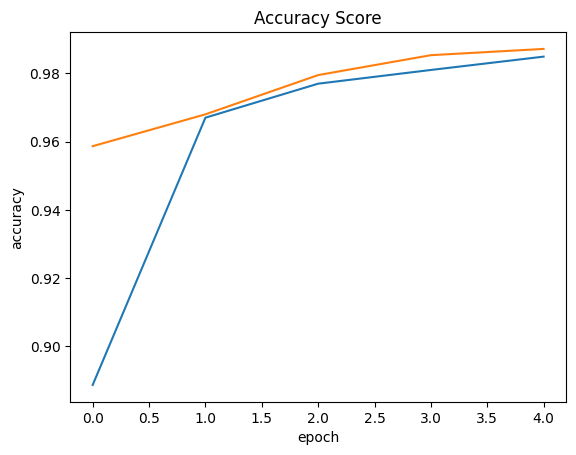

In [ ]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='epoch')
plt.title("Accuracy Score")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

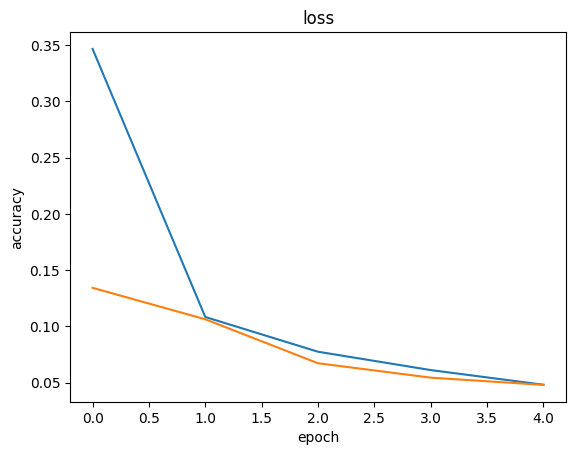

In [ ]:
plt.plot(history.history['loss'],label='Accuracy')
plt.plot(history.history['val_loss'],label='epoch')
plt.title("loss")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()